In [1]:
import sys
print("Python executable:", sys.executable)

import numpy as np
import pandas as pd
import scipy
import statsmodels
import dill
import torch
import matplotlib

print("numpy", np.__version__)
print("pandas", pd.__version__)
print("scipy", scipy.__version__)
print("matplotlib", matplotlib.__version__)
print("statsmodels", statsmodels.__version__)
print("dill", dill.__version__)
print("torch", torch.__version__, "cuda available:", torch.cuda.is_available())

Python executable: /blue/juannanzhou/arindam.sarkar/.conda/envs/gpy4/bin/python
numpy 2.3.1
pandas 2.3.3
scipy 1.17.0
matplotlib 3.10.3
statsmodels 0.14.6
dill 0.4.1
torch 2.7.1 cuda available: False


In [2]:
import sys
from pathlib import Path
import importlib

PROJECT_ROOT = Path("/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/4_qtl_inference")
sys.path.insert(0, str(PROJECT_ROOT))

import src.prepare_data
importlib.reload(src.prepare_data)

from src.prepare_data import yeast_geno_data, yeast_fitness_data, yeast_data, get_abs_pos

In [3]:
from pathlib import Path

paths = [
    Path("/orange/juannanzhou/MarginalEpistasis/data/geno_top_60.npy"),  # adjust if needed
    Path("/orange/juannanzhou/MarginalEpistasis/data/index_top_60.tsv"),
    Path("/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/4_qtl_inference/data/snp_info_complete.tsv"),
    Path("/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/4_qtl_inference/data/gene_info.csv"),
]
for p in paths:
    print(p, "exists:", p.exists())

/orange/juannanzhou/MarginalEpistasis/data/geno_top_60.npy exists: True
/orange/juannanzhou/MarginalEpistasis/data/index_top_60.tsv exists: True
/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/4_qtl_inference/data/snp_info_complete.tsv exists: True
/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/4_qtl_inference/data/gene_info.csv exists: True


In [4]:
def get_abs_pos(chrom, chrom_pos):
    return (chrom_pos - 1) + dict(enumerate(chr_offsets))[chrom - 1]    


yeast_chr_lengths = [
    230218, 813184, 316620, 1531933, 576874, 270161, 1090940, 562643,
    439888, 745751, 666816, 1078177, 924431, 784333, 1091291, 948066
]

yeast_chr_size = np.array(yeast_chr_lengths).sum()

chr_labels_arabic = [str(i) for i in range(1, 17)]
chr_offsets = np.cumsum([0] + yeast_chr_lengths[:-1])

def calc_LOD_vectorized(y, X):
    """
    Vectorized function for calculating log odds 
    X: n X L; binary genotype matrix
    y: n
    """
    X_ = -1 * (X - 1)
    n = len(y)
    means = np.matmul(y.T, X) / X.sum(axis=0)
    means_ = np.matmul(y.T, X_) / X_.sum(axis=0)
    preds = (X * means) + (X_ * means_)
    res = (preds.T - y) # residuals
    rss1 = np.var(res, axis=1)
    rss0 = np.var(y)
    lods = (n / 2.0) * np.log10(rss0 / rss1)
    
    return lods

### Load data

In [5]:
# load genotype data

path = Path("/orange/juannanzhou/MarginalEpistasis/data/")
geno_data_path = path / "geno_top_60.npy"
ids_path = path / "index_top_60.tsv"
snp_info_path = "/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/4_qtl_inference/data/snp_info_complete.tsv"
gene_info_path = "/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/4_qtl_inference/data/gene_info.csv"

### three ways to code SNP position: SNP index; Absolute genomic position [0, sum of chrom sizes]; Chromosome position (chrom, position)
geno_data = yeast_geno_data(geno_data_path, ids_path, snp_info_path, gene_info_path, gpu_device="cpu") #change to 'gpu'while on a GPU node! 
print(geno_data.geno_t.device)
geno_data.snp_info = geno_data.snp_info.drop(columns='Index')
geno_data.snp_info['abs_pos'] = [get_abs_pos(*list(geno_data.snp_info.loc[i][['Chromosome', 'Position (bp)']])) for i in range(len(geno_data.snp_info))]
geno_data.sub_sample_snps(r2_threshold=1) # only retain SNPs not in complete LD 

[yeast_geno_data] Using device: cpu
cpu


In [6]:
print("Total SNPs:", geno_data.snp_info.shape[0])
print("SNPs retained:", len(geno_data.loci_chosen))

Total SNPs: 41594
SNPs retained: 37339


In [7]:
# fitness data
treatment = 'Fluconazole'
conditions = ['CON', 'QMIC', 'HMIC', 'FMIC']

dfs_indexed = []
for con in conditions:
    file = f"/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/results/Joint_inference/Filtered/FLU/{con}/fitness_ALLreps_with_ids.tsv"
    df = pd.read_csv(file, sep="\t")
    dfs_indexed.append(df.set_index("ID")[["s", "stderr(s)"]])

dfs_merged = pd.concat(dfs_indexed, axis=1).dropna()
dfs_merged = dfs_merged.rename(columns={"s": "mean_log_fit", "stderr(s)": "std_log_fit"})

fitness_data = yeast_fitness_data(treatment, conditions, in_path=None)
fitness_data.df_fits = dfs_merged

In [8]:
# combine genotype and phenotype data
data = yeast_data(geno_data, fitness_data)
main_effects = data.get_main_effects(geno_data.loci_chosen)

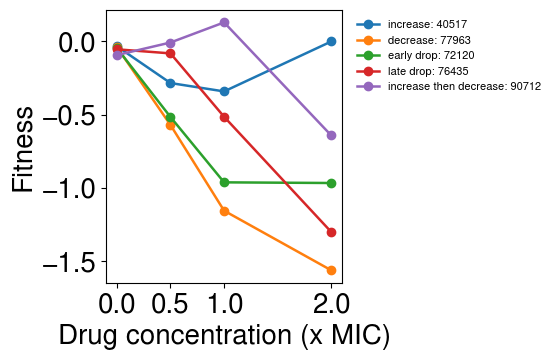

In [9]:
# --- Plot 1: Diverse representative lineage trajectories across Pulvinatal concentrations ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

conditions_numeric = np.array([0.0, 0.5, 1.0, 2.0])

fitness_mat = data.fitness["mean_log_fit"].copy()
fitness_mat.columns = conditions_numeric

# Basic trajectory features
features = pd.DataFrame(index=fitness_mat.index)
features["start"] = fitness_mat[0.0]
features["end"] = fitness_mat[2.0]
features["delta"] = fitness_mat[2.0] - fitness_mat[0.0]
features["min"] = fitness_mat.min(axis=1)
features["max"] = fitness_mat.max(axis=1)
features["range"] = features["max"] - features["min"]

features["early_delta"] = fitness_mat[0.5] - fitness_mat[0.0]
features["mid_delta"] = fitness_mat[1.0] - fitness_mat[0.5]
features["late_delta"] = fitness_mat[2.0] - fitness_mat[1.0]

# Pick 5 diverse representative patterns
representatives = {}

# 1. Strong increase from 0 to 2x MIC
representatives["increase"] = features["delta"].idxmax()

# 2. Strong decrease from 0 to 2x MIC
representatives["decrease"] = features["delta"].idxmin()

# 3. Early sharp drop, then mostly flat
early_drop_score = (-features["early_delta"]) - abs(features["late_delta"])
representatives["early drop"] = early_drop_score.idxmax()

# 4. Late drop: stable early, then decreases later
late_drop_score = (-features["late_delta"]) - abs(features["early_delta"])
representatives["late drop"] = late_drop_score.idxmax()

# 5. Increase then decrease, i.e. peaked trajectory
peak_score = fitness_mat[1.0] - fitness_mat[[0.0, 2.0]].mean(axis=1)
representatives["increase then decrease"] = peak_score.idxmax()

# Remove accidental duplicates while preserving order
selected_ids = []
selected_labels = []

for label, strain_id in representatives.items():
    if strain_id not in selected_ids:
        selected_ids.append(strain_id)
        selected_labels.append(label)

plt.figure(figsize=(6, 4))

for strain_id, label in zip(selected_ids, selected_labels):
    plt.plot(
        conditions_numeric,
        fitness_mat.loc[strain_id].values,
        marker="o",
        linewidth=1.8,
        label=f"{label}: {strain_id}"
    )

plt.xticks(conditions_numeric, conditions_numeric)
plt.xlabel("Drug concentration (x MIC)")
plt.ylabel("Fitness")
# plt.title("Diverse representative lineage fitness trajectories")
plt.legend(fontsize=8, frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

# plt.savefig("figures/diverse_representative_lineage_trajectories.pdf", bbox_inches="tight")
plt.show()

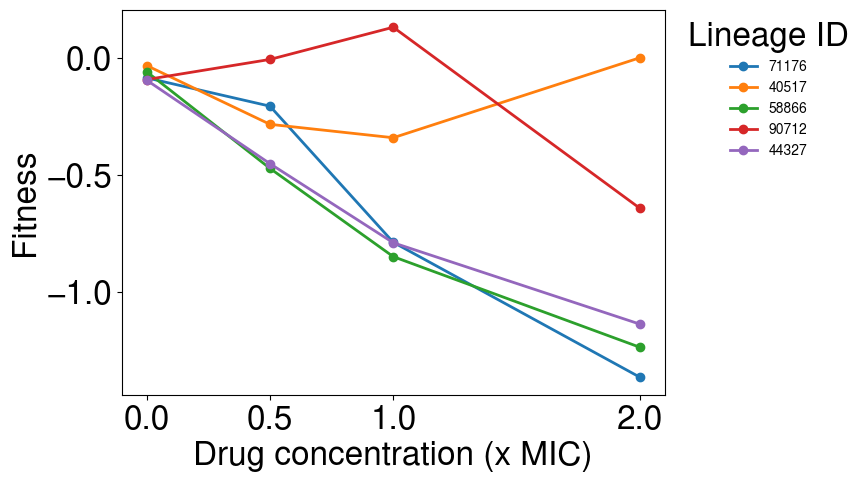

In [42]:
# --- Plot 1 (manual): Plot specific lineage trajectories across Pulvinatal concentrations ---

import numpy as np
import matplotlib.pyplot as plt

# Specify Pulvinatal concentrations
PUL_CONDITIONS = np.array([0.0, 0.5, 1.0, 2.0])

# Manually specify lineage IDs to plot
LINEAGE_IDS = [
    71176,
    40517,
    58866,
    90712,
    44327
]

# Load fitness matrix
fitness_mat = data.fitness["mean_log_fit"].copy()
fitness_mat.columns = PUL_CONDITIONS

plt.figure(figsize=(7, 5))

for lineage_id in LINEAGE_IDS:

    # Skip if lineage missing
    if lineage_id not in fitness_mat.index:
        print(f"Skipping missing lineage: {lineage_id}")
        continue

    y = fitness_mat.loc[lineage_id].values

    plt.plot(
        PUL_CONDITIONS,
        y,
        marker="o",
        linewidth=2,
        markersize=6,
        label=str(lineage_id)
    )

plt.xticks(PUL_CONDITIONS, PUL_CONDITIONS)
plt.xlabel("Drug concentration (x MIC)")
plt.ylabel("Fitness")

plt.legend(
    title="Lineage ID",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=10
)

# plt.tight_layout(rect=[0, 0, 0.85, 1])

# plt.savefig("figures/manual_lineage_trajectories_FLU.pdf",dpi=300, bbox_inches="tight")

plt.show()

In [43]:
# --- Find lead SNP/locus index near ERG11 using existing paths and geno_data ---

GENE_QUERY = "SNO4"
PADDING = 10000

gene_info_df = pd.read_csv(gene_info_path)

gene_row = gene_info_df[
    (gene_info_df["Standard_name"].astype(str).str.upper() == GENE_QUERY) |
    (gene_info_df["gene_name"].astype(str).str.upper() == GENE_QUERY)
].copy()

display(gene_row)

chrom = int(gene_row.iloc[0]["chrom"])
start = int(gene_row.iloc[0]["gene_chr_start"])
end = int(gene_row.iloc[0]["gene_chr_end"])

print(f"{GENE_QUERY}: chr{chrom}:{start}-{end}")

candidate_snps = geno_data.snp_info[
    (geno_data.snp_info["Chromosome"] == chrom) &
    (geno_data.snp_info["Position (bp)"] >= start - PADDING) &
    (geno_data.snp_info["Position (bp)"] <= end + PADDING)
].copy()

display(candidate_snps)

ERG11_LOCUS = candidate_snps.index[
    np.argmin(
        np.abs(candidate_snps["Position (bp)"] - ((start + end) / 2))
    )
]

print(f"Use this ERG11 locus index: {ERG11_LOCUS}")

,gene_name,chrom,gene_chr_start,gene_chr_end,Standard_name


IndexError: single positional indexer is out-of-bounds

/scratch/local/34498579/ipykernel_183546/1288450381.py:95: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/scratch/local/34498579/ipykernel_183546/1288450381.py:97: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/GRC/main_effect_SPC72_ERG11_FLU.png", dpi=300, bbox_inches="tight")
/blue/juannanzhou/arindam.sarkar/.conda/envs/gpy4/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


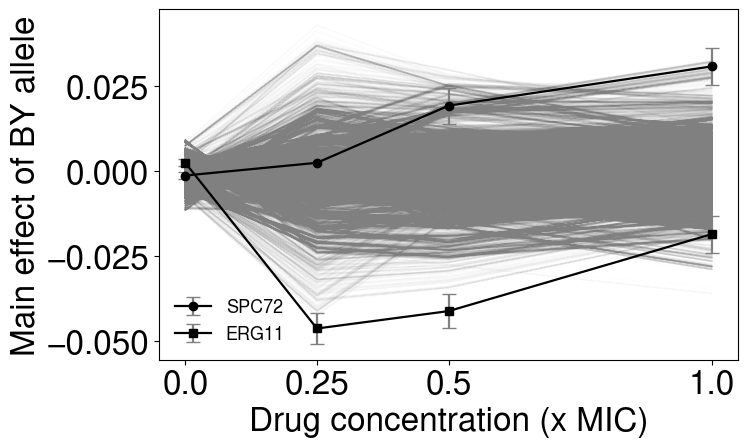

In [45]:
# --- Plot 2: Main effect of BY allele across Pulvinatal concentrations ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PUL_CONDITIONS = np.array([0.0, 0.25, 0.5, 1.0])

def generate_main_effect_plot_data(locus, data, n_boot=1000, sample_n=1000, random_state=1):
    rng = np.random.default_rng(random_state)
    main_effects_samples = []

    df_BY = data.fitness[data.geno[:, locus] == 0]["mean_log_fit"].copy()
    df_RM = data.fitness[data.geno[:, locus] == 1]["mean_log_fit"].copy()

    df_BY.columns = PUL_CONDITIONS
    df_RM.columns = PUL_CONDITIONS

    for _ in range(n_boot):
        by_sample = df_BY.sample(
            n=sample_n,
            replace=True,
            random_state=int(rng.integers(1e9))
        ).mean(axis=0)

        rm_sample = df_RM.sample(
            n=sample_n,
            replace=True,
            random_state=int(rng.integers(1e9))
        ).mean(axis=0)

        main_effects_samples.append(by_sample - rm_sample)

    main_effects_samples = pd.concat(main_effects_samples, axis=1).T

    plotdata = pd.DataFrame({
        "condition": PUL_CONDITIONS,
        "mean_effect": main_effects_samples.mean(axis=0).values,
        "std": main_effects_samples.std(axis=0).values
    })

    return plotdata


plt.figure(figsize=(8, 5))

# Background trajectories for most SNPs
main_effects_plot = main_effects.copy()
main_effects_plot.columns = PUL_CONDITIONS

threshold = main_effects_plot.var(axis=1).quantile(0.90)
plotdata_bg = main_effects_plot[main_effects_plot.var(axis=1) < threshold]

plt.plot(
    plotdata_bg.T,
    color="gray",
    alpha=0.01,
    linewidth=1
)

# Highlight loci of interest
loci_to_plot = {
    "SPC72": {"locus": 338, "fmt": "o-"},
    "ERG11": {"locus": 16910, "fmt": "s-"}
}

for gene, params in loci_to_plot.items():
    plotdata = generate_main_effect_plot_data(
        locus=params["locus"],
        data=data,
        random_state=1
    )

    plt.errorbar(
        plotdata["condition"],
        plotdata["mean_effect"],
        yerr=plotdata["std"],
        fmt=params["fmt"],
        capsize=5,
        color="black",
        ecolor="gray",
        markerfacecolor="black",
        markeredgecolor="black",
        linewidth=1.6,
        label=gene
    )

plt.xticks(PUL_CONDITIONS, PUL_CONDITIONS)
plt.xlabel("Drug concentration (x MIC)")
plt.ylabel("Main effect of BY allele")
plt.legend(
    fontsize=13,
    frameon=False
)
plt.tight_layout()

plt.savefig("/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/GRC/main_effect_SPC72_ERG11_FLU.png", dpi=300, bbox_inches="tight")
plt.show()

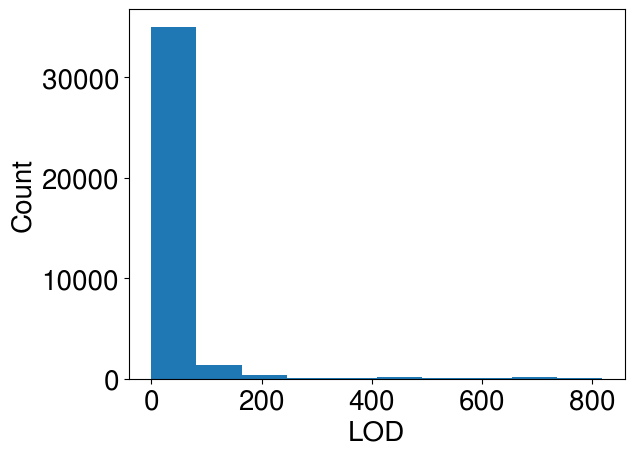

In [10]:
import matplotlib.pyplot as plt

X = data.geno[:, geno_data.loci_chosen]
y = np.array(data.fitness['mean_log_fit'].iloc[:, 1])

lods = calc_LOD_vectorized(y, X) # calculate log odds

plt.hist(lods)
plt.xlabel("LOD")
plt.ylabel("Count")
plt.show()

In [9]:
treatments = ['C', 'Q', 'H', 'F']

X = data.geno[:, geno_data.loci_chosen]

LODS_df = {}

for i in range(4):
    y = np.array(data.fitness['mean_log_fit'].iloc[:, i])
    lods = calc_LOD_vectorized(y, X)
    LODS_df[treatments[i]] = lods

LODS_df = pd.DataFrame(LODS_df)

LODS_df.index = geno_data.loci_chosen

In [10]:
X.shape

(10513, 37339)

### Make Manhattan plot

In [20]:
snp_gene_info_df = pd.read_csv("./data/snp_info_complete.tsv", sep="\t")
gene_info_df = pd.read_csv("./data/gene_info.csv")

# Separate plotting vs results parameters
LABEL_THRESHOLD = 1.5
LABEL_WINDOW = 100

QTL_PEAK_THRESHOLD = 1.5
QTL_PEAK_WINDOW = 100


def make_man(df_plot, snp_info, ax, value, bg_color=None, ylab=None, ylim=None,
             label_genes=False, chrom=None, chrom_range=None,
             constrained_layout=False,
             label_threshold=LABEL_THRESHOLD,
             label_window=LABEL_WINDOW):

    df_plot, df_plot_max = make_df_plot(
        df_plot,
        snp_info,
        y_threshold=label_threshold,
        value=value,
        percentage=False,
        window=label_window
    )

    abs_pos = df_plot_max["abs_pos"]
    y = df_plot_max[value]

    ax.set_box_aspect(1/6)

    # Plot top LOD peaks
    ax.bar(
        abs_pos,
        y,
        width=20000,
        color="black"
    )

    # Main LOD track
    ax.plot(
        df_plot["abs_pos"],
        df_plot[value],
        color="gray",
        lw=1.5,
        zorder=2,
        alpha=0.4
    )

    # ---------------------------------------------------------
    # NO-PLEIOTROPY VERSION (enabled)
    # ---------------------------------------------------------
    pass

    # ---------------------------------------------------------
    # NORMAL VERSION WITH PLEIOTROPY TRACK (comment out)
    # ---------------------------------------------------------
    if bg_color is not None:
        ax.plot(
            bg_color["abs_pos"],
            200 * bg_color["CI_track"]
        )

    # Y limits
    if ylim is not None:
        ax.set_ylim(ylim)
    else:
        ax.set_ylim(0, max(12, df_plot[value].max() * 1.15))

    # Gene labels
    if label_genes:
        for _, row in df_plot_max.iterrows():

            name = row["gene"]
            x = row["abs_pos"]
            y = row[value]

            ax.annotate(
                name,
                xy=(x, y),
                xytext=(0, 5),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=10,
                color="gray"
            )

    # Chromosome boundaries
    for offset in chr_offsets[1:]:
        ax.axvline(
            offset,
            color="lightgray",
            lw=2,
            zorder=0
        )

    # Chromosome labels
    midpoints = [
        offset + length / 2
        for offset, length in zip(chr_offsets, yeast_chr_lengths)
    ]

    ax.set_xticks(midpoints)
    ax.set_xticklabels(
        chr_labels_arabic,
        fontsize=12,
        fontweight="bold"
    )

    # X limits
    if chrom is None:
        ax.set_xlim(0, yeast_chr_size)

    else:
        c_idx = chrom - 1

        if chrom_range is None:
            ax.set_xlim(
                chr_offsets[c_idx],
                chr_offsets[c_idx + 1]
            )

        else:
            ax.set_xlim(
                chr_offsets[c_idx] + chrom_range[0],
                chr_offsets[c_idx] + chrom_range[1]
            )

    ax.set_xlabel("Chromosome", fontsize=18)
    ax.set_ylabel(f"{ylab}", fontsize=18)

    ax.margins(x=0)

    return ax


def make_df_plot(
    df_input,
    snp_info,
    y_threshold=10,
    value="LOD",
    percentage=False,
    get_local_min=False,
    threshold_min=None,
    window=30
):
    df_plot = df_input.copy()

    if isinstance(df_plot, pd.Series):
        df_plot = pd.DataFrame(df_plot)

    if value not in df_plot.columns:
        df_plot = df_plot.rename(
            columns={df_plot.columns[0]: value}
        )

    # Optional percentage scaling
    if percentage:
        df_plot[value] = df_plot[value] * 100

    # Add SNP annotation
    df_plot["abs_pos"] = snp_info.loc[
        df_plot.index,
        "abs_pos"
    ].values

    df_plot["gene"] = snp_info.loc[
        df_plot.index,
        "gene_standard_name"
    ].values

    # Local minima threshold
    if threshold_min is None:
        y_threshold_min = df_plot[value].quantile(0.01)
    else:
        y_threshold_min = threshold_min

    peaks = []
    l = len(df_plot)

    for i in range(l):

        start = max(0, i - window)
        end = min(i + window + 1, l)

        local_max = (
            np.abs(df_plot[value].iloc[i])
            ==
            np.abs(df_plot[value].iloc[start:end]).max()
        )

        threshold = (
            df_plot[value].iloc[i]
            > y_threshold
        )

        if get_local_min:

            local_min = (
                np.abs(df_plot[value].iloc[i])
                ==
                np.abs(df_plot[value].iloc[start:end]).min()
            )

            threshold_min_pass = (
                df_plot[value].iloc[i]
                < y_threshold_min
            )

            peaks.append(
                (local_max & threshold)
                |
                (local_min & threshold_min_pass)
            )

        else:
            peaks.append(local_max & threshold)

    df_plot_max = df_plot.loc[peaks].copy()

    return df_plot, df_plot_max

In [21]:
snp_info = geno_data.snp_info
# print("After 0.90:", geno_data.snp_info.shape[0])
# print("After 1:", geno_data.snp_info.shape[0])

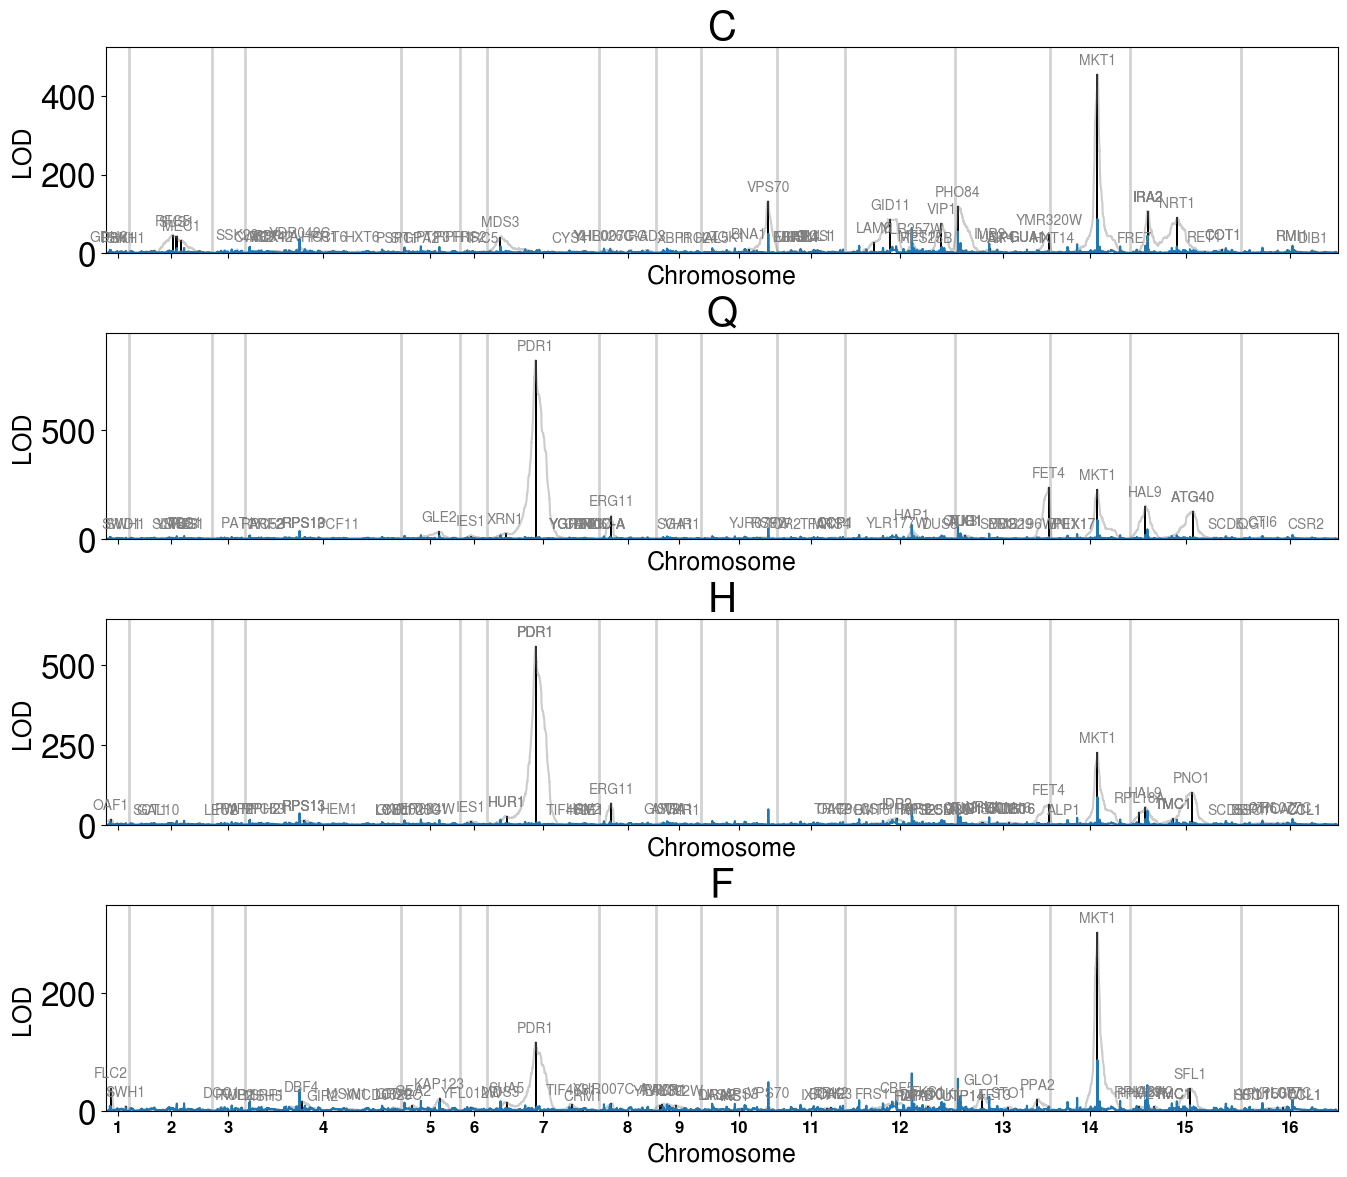

In [22]:
import matplotlib.pyplot as plt

pleio_track = pd.read_csv("data/pleiotropic_CI.csv")
geno_data.snp_info["pleio_score"] = list(pleio_track.loc[geno_data.snp_info.abs_pos]["CI_track"])

plt.rcParams.update({
    "font.size": 24,
    "font.family": "Nimbus Sans"
})

treatments = ["C", "Q", "H", "F"]

fig, axs = plt.subplots(len(treatments), 1, sharex=True, figsize=(14, 12))

for ax, treatment in zip(axs, treatments):
    df_plot = pd.DataFrame({"LOD": LODS_df[treatment]})

    make_man(
        df_plot,
        geno_data.snp_info,
        ax,
        "LOD",
        bg_color=pleio_track,
        ylab="LOD",
        label_genes=True,
        label_threshold=LABEL_THRESHOLD,
        label_window=LABEL_WINDOW
    )

    ax.set_title(f"{treatment}")

fig.subplots_adjust(left=0.2, hspace=0)
fig.align_ylabels(axs)

plt.tight_layout()

# fig.savefig("figures/Fluconazole_LOD05_Pleio.pdf", format="pdf", bbox_inches="tight")
fig.savefig("figures/Fluconazole_LOD01_Pleio.png", format="png", bbox_inches="tight")

plt.show()

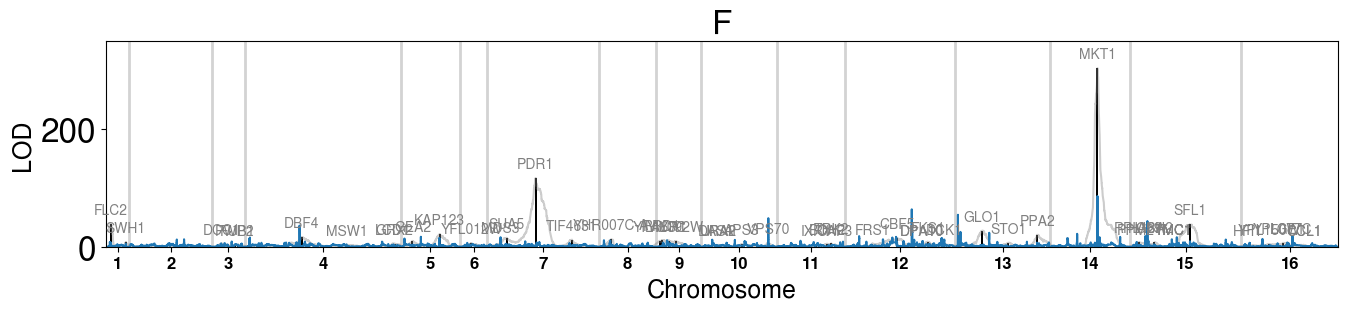

In [14]:
# ==========================================================
# Plot Manhattan for a single condition
# ==========================================================

CONDITION = "F"   # choose from: "C", "Q", "H", "F"

assert CONDITION in ["C", "Q", "H", "F"], (
    "CONDITION must be one of: C, Q, H, F"
)

plt.rcParams.update({
    "font.size": 24,
    "font.family": "Nimbus Sans"
})

fig, ax = plt.subplots(
    1, 1,
    figsize=(14, 4)
)

# Build dataframe for selected condition
df_plot = pd.DataFrame({
    "LOD": LODS_df[CONDITION]
})

# Generate Manhattan plot
make_man(
    df_plot,
    geno_data.snp_info,
    ax,
    "LOD",
    bg_color=pleio_track,
    ylab="LOD",
    label_genes=True,
    label_threshold=LABEL_THRESHOLD,
    label_window=LABEL_WINDOW
)

ax.set_title(
    f"{CONDITION}",
    fontsize=24
)

plt.tight_layout()

# Save figure
fig.savefig(
    f"figures/Fluconazole_{CONDITION}_LOD05_noPleio.pdf",
    format="pdf",
    bbox_inches="tight"
)

# fig.savefig(
#     f"figures/Pulvinatal_{CONDITION}_LOD_noPleio.png",
#     format="png",
#     bbox_inches="tight"
# )

plt.show()

In [15]:
CONDITION = "F"

df_plot = pd.DataFrame({
    "LOD": LODS_df[CONDITION]
})

df_plot_full, df_plot_max = make_df_plot(
    df_plot,
    geno_data.snp_info,
    y_threshold=LABEL_THRESHOLD,
    value="LOD",
    percentage=False,
    window=LABEL_WINDOW
)

# Inspect available columns
print(geno_data.snp_info.columns.tolist())

# Add chromosome if available
if "Chromosome" in geno_data.snp_info.columns:
    df_plot_max["Chromosome"] = geno_data.snp_info.loc[
        df_plot_max.index, "Chromosome"
    ].values
elif "chrom" in geno_data.snp_info.columns:
    df_plot_max["Chromosome"] = geno_data.snp_info.loc[
        df_plot_max.index, "chrom"
    ].values

# Add position if available
if "Position" in geno_data.snp_info.columns:
    df_plot_max["Position"] = geno_data.snp_info.loc[
        df_plot_max.index, "Position"
    ].values
elif "position" in geno_data.snp_info.columns:
    df_plot_max["Position"] = geno_data.snp_info.loc[
        df_plot_max.index, "position"
    ].values
elif "pos" in geno_data.snp_info.columns:
    df_plot_max["Position"] = geno_data.snp_info.loc[
        df_plot_max.index, "pos"
    ].values
else:
    df_plot_max["Position"] = np.nan

df_plot_max_sorted = df_plot_max.sort_values("abs_pos")

display(
    df_plot_max_sorted[
        ["Chromosome", "Position", "abs_pos", "gene", "LOD"]
    ]
)

['SNP', 'Chromosome', 'Position (bp)', 'BY allele', 'RM allele', 'feature_type', 'gene_name', 'gene_chr_start', 'gene_chr_end', 'gene_standard_name', 'abs_pos', 'pleio_score']


,Chromosome,Position,abs_pos,gene,LOD
268,1,NaN,48114,FLC2,39.443184
899,1,NaN,195458,SWH1,7.502975
4916,3,NaN,1139321,DCC1,5.401984
5058,3,NaN,1264681,PWP2,3.464777
5207,3,NaN,1293521,FUB1,3.562601
7159,4,NaN,1919482,DBF4,16.060537
7981,4,NaN,2364102,MSW1,3.699054
8667,4,NaN,2807451,LCD1,5.150220
8894,4,NaN,2831279,GRX2,5.227263
9815,5,NaN,3004373,GEA2,9.940598


In [16]:
# ==========================================================
# Print labels within chromosome range
# ==========================================================

CHR_START = 15
CHR_END = 16

# Convert chromosome column to string for robust matching
chrom_col = df_plot_max_sorted["Chromosome"].astype(str)

# Build accepted chromosome names
allowed_chr = []

roman_map = {
    1: "I", 2: "II", 3: "III", 4: "IV",
    5: "V", 6: "VI", 7: "VII", 8: "VIII",
    9: "IX", 10: "X", 11: "XI", 12: "XII",
    13: "XIII", 14: "XIV", 15: "XV", 16: "XVI"
}

for c in range(CHR_START, CHR_END + 1):
    allowed_chr.extend([
        str(c),
        c,
        f"chr{roman_map[c]}",
        roman_map[c]
    ])

# Filter chromosome range
crowded = df_plot_max_sorted[
    chrom_col.isin(
        [str(x) for x in allowed_chr]
    )
]

display(
    crowded[
        ["Chromosome", "Position", "abs_pos", "gene", "LOD"]
    ]
    .sort_values(["Chromosome", "Position"])
)

,Chromosome,Position,abs_pos,gene,LOD
35892,15,NaN,10126413,RPL18A,40.870146
36238,15,NaN,10183677,HAL9,56.812105
37496,15,NaN,10458727,TMC1,20.128630
37497,15,NaN,10458735,TMC1,20.128630
37498,15,NaN,10458755,TMC1,20.128630
37499,15,NaN,10458806,TMC1,20.128630
38631,15,NaN,10638200,PNO1,102.679756
40085,16,NaN,11328282,CTI6,6.947510
40544,16,NaN,11533030,YPL077C,6.931873
40698,16,NaN,11581892,OAZ1,6.479819


In [17]:
print("LODS_df shape:", LODS_df.shape)
print("LODS_df index head:", LODS_df.index[:10])

print("snp_info shape:", geno_data.snp_info.shape)
print("snp_info index head:", geno_data.snp_info.index[:10])

print("snp_info columns:", geno_data.snp_info.columns.tolist())

LODS_df shape: (37339, 4)
LODS_df index head: Index([0, 1, 2, 3, 4, 6, 12, 13, 15, 19], dtype='int64')
snp_info shape: (41594, 12)
snp_info index head: Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype='int64')
snp_info columns: ['SNP', 'Chromosome', 'Position (bp)', 'BY allele', 'RM allele', 'feature_type', 'gene_name', 'gene_chr_start', 'gene_chr_end', 'gene_standard_name', 'abs_pos', 'pleio_score']


In [18]:
# Export per-SNP LOD table using the SNP subset that matches LODS_df

lod_export = pd.DataFrame(LODS_df).copy()

# Align snp_info to the LODS_df subset using index
snp_info_subset = geno_data.snp_info.loc[LODS_df.index].copy()

# Add SNP identity columns if available
insert_pos = 0

if "Index" in snp_info_subset.columns:
    lod_export.insert(insert_pos, "Index", snp_info_subset["Index"].values)
    insert_pos += 1

if "SNP" in snp_info_subset.columns:
    lod_export.insert(insert_pos, "SNP", snp_info_subset["SNP"].values)
    insert_pos += 1

# Optional useful columns
if "Chromosome" in snp_info_subset.columns:
    lod_export.insert(insert_pos, "Chromosome", snp_info_subset["Chromosome"].values)
    insert_pos += 1

if "Position (bp)" in snp_info_subset.columns:
    lod_export.insert(insert_pos, "Position (bp)", snp_info_subset["Position (bp)"].values)
    insert_pos += 1

lod_export.to_csv("data/Pulvinatal_LOD_per_snp.csv", index=False)

print(lod_export.shape)
lod_export.head()

(37339, 7)


,SNP,Chromosome,Position (bp),C,Q,H,F
0,snp1,1,27210,2.357785,0.075305,11.741479,28.431543
1,snp2,1,27290,2.373484,0.075117,11.750924,28.338982
2,snp3,1,27356,2.334453,0.073683,11.757222,28.314775
3,snp4,1,27357,2.334453,0.073683,11.757222,28.314775
4,snp5,1,27370,2.315476,0.074460,11.736573,28.298480


In [23]:
test_lod = pd.read_csv("data/Pulvinatal_LOD_per_snp.csv")
print(test_lod.shape)
print(test_lod.columns.tolist())
test_lod.head()

(37339, 7)
['SNP', 'Chromosome', 'Position (bp)', 'C', 'H', 'F', 'D']


,SNP,Chromosome,Position (bp),C,H,F,D
0,snp1,1,27210,1.530708,134.600075,124.905667,74.193223
1,snp2,1,27290,1.552951,134.521658,124.752968,74.114626
2,snp3,1,27356,1.543347,134.719018,125.096943,74.437818
3,snp4,1,27357,1.543347,134.719018,125.096943,74.437818
4,snp5,1,27370,1.538815,134.537615,124.909982,74.259026


### generate summaries

In [23]:
snp_gene_info_df = pd.read_csv("./data/snp_info_complete.tsv", sep='\t')
gene_info_df = pd.read_csv("./data/gene_info.csv")

# Functions for generating the summary table of QTL results

def find_limit(peak, track, snp_info, threshold, step):
    # find the segment of SNPs containing causal SNP with 95 percent confidence
    chrom = snp_info['Chromosome'][peak] # chrom number of the peak
    pos = np.where(track.index == peak)[0][0] # position of the peak on the input track df, not SNP id
    i = 0
    while (track.iloc[pos + i] > threshold) & (snp_info['Chromosome'][list(track.index)[pos + i]] == chrom):
        i += step
        i = int(i)
    return list(track.index)[pos + i - 1]

def get_lod_interval(peak, lod_track, snp_info, tolerance=1.5):
    """
    peak: id of peak snp in original indexing (42000 snps)
    """
    # peak_id = np.where(lod_track.index == peak)[0][0]
    threshold = lod_track.loc[peak] - tolerance
    limits_id = [find_limit(peak, lod_track, snp_info, threshold, -1), find_limit(peak, lod_track, snp_info, threshold, +1)]
    # limits = [lod_track.index[limits_id[0]], lod_track.index[limits_id[1]]]
    
    return limits_id

def map_to_chr_pos(snp_id, snp_info):
    """
    snp_info: panda df with SNP id as index, contaning columns
    'Chromsome' and 'Position (bp)'
    """
    chrom = snp_info.loc[snp_id]['Chromosome']
    pos = snp_info.loc[snp_id]['Position (bp)']
    return chrom, pos

def get_seg_chrom_pos(seg_start, seg_end, snp_info):
    (seg_chrom, seg_chr_start), (_, seg_chr_end) = map_to_chr_pos(seg_start, snp_info), map_to_chr_pos(seg_end, snp_info)
    
    return seg_chrom, seg_chr_start, seg_chr_end

def gene_in_interval(gene_info, seg_info, padding=0):
    """
    gene_info, seg_info: chrom, chrom_start, chrom_end
    """
    gene_chrom, gene_chr_start, gene_chr_end = gene_info
    seg_chrom, seg_chr_start, seg_chr_end = seg_info
    
    if gene_chrom == seg_chrom:
        gene_range = np.arange(gene_chr_start, gene_chr_end)
        seg_range = np.arange(seg_chr_start - padding, seg_chr_end + padding)
        overlap = np.intersect1d(gene_range, seg_range)
        
        return len(overlap) != 0
    else: 
        return False

def get_all_genes_in_segment(seg_info, gene_info_df):
    genes_in_segment = []
    genes_in_segment_std = []
    for i in range(len(gene_info_df)):
        gene_info = list(gene_info_df.iloc[i][["chrom", "gene_chr_start", "gene_chr_end"]])
        gene_name, gene_standard_name = gene_info_df.iloc[i][['gene_name', 'Standard_name']]
        if gene_in_interval(gene_info, seg_info, padding=1000):
            genes_in_segment.append(gene_name)
            genes_in_segment_std.append(gene_standard_name)
    return ", ".join(genes_in_segment), ", ".join(genes_in_segment_std)

In [27]:
treatment = "Q"

df_plot = pd.DataFrame({
    "LOD": LODS_df[treatment]
})

df_plot, df_plot_max = make_df_plot(
    df_plot,
    snp_info,
    y_threshold=QTL_PEAK_THRESHOLD,
    value="LOD",
    percentage=False,
    window=QTL_PEAK_WINDOW
)

peaks = list(df_plot_max.index)
lod_track = df_plot["LOD"]

In [28]:
# find overlapping genes

intervals = {}
for peak in peaks:
    try:
        intervals[peak] = get_lod_interval(peak, lod_track, geno_data.snp_info, tolerance=2.)
    except: 
        pass

In [26]:
from scipy import stats

interval_df = {}

for interval_id in intervals.keys():
    seg_start, seg_end = intervals[interval_id]
    seg_info = get_seg_chrom_pos(seg_start, seg_end, geno_data.snp_info)
    seg_chrom, seg_start, seg_end = seg_info
    
    genes_in_segment, genes_in_segment_std = get_all_genes_in_segment(seg_info, gene_info_df)
    
    abs_start, abs_end = get_abs_pos(seg_chrom, seg_start), get_abs_pos(seg_chrom, seg_end)
    seg_pleio_score = pleio_track[abs_start: abs_end].CI_track.max()
    seg_pleio_percentile = stats.percentileofscore(geno_data.snp_info.loc[geno_data.loci_chosen]['pleio_score'], seg_pleio_score, kind='rank')
    
    df_data = {"interval_id": interval_id, "chrom": seg_chrom, "start": seg_start, "end": seg_end, 
               "genes": genes_in_segment, "genes_std": genes_in_segment_std, 'pleio_score': seg_pleio_score, 
              'pleio_percentile': seg_pleio_percentile}
    interval_df[interval_id] = df_data

interval_df = pd.DataFrame(interval_df).T
interval_df['lod_max'] = lod_track.loc[peaks]

interval_df.to_csv("results/Fluconazole_QTL_F_LOD01_20260806.csv", index=None)

In [23]:
interval_df['n_genes'] = [len(s.split(",")) for s in interval_df.genes]

In [24]:
interval_df.sort_values(by='n_genes', ascending=True)

,interval_id,chrom,start,end,genes,genes_std,pleio_score,pleio_percentile,lod_max,n_genes
32760,32760,13,371117,625679,"YMR049C, YMR052W, YMR052C-A, YMR053C, YMR054W,...","ERB1, FAR3, FAR3, STB2, STV1, BUB2, AAC1, AAC1...",0.041321,98.916682,5.344599,122
32759,32759,13,371117,625679,"YMR049C, YMR052W, YMR052C-A, YMR053C, YMR054W,...","ERB1, FAR3, FAR3, STB2, STV1, BUB2, AAC1, AAC1...",0.041321,98.916682,5.344599,122
32362,32362,13,378957,621124,"YMR052W, YMR052C-A, YMR053C, YMR054W, YMR055C,...","FAR3, FAR3, STB2, STV1, BUB2, AAC1, AAC1, FET3...",0.041321,98.916682,5.748055,120
32363,32363,13,378957,621124,"YMR052W, YMR052C-A, YMR053C, YMR054W, YMR055C,...","FAR3, FAR3, STB2, STV1, BUB2, AAC1, AAC1, FET3...",0.041321,98.916682,5.748055,120
32364,32364,13,378957,621124,"YMR052W, YMR052C-A, YMR053C, YMR054W, YMR055C,...","FAR3, FAR3, STB2, STV1, BUB2, AAC1, AAC1, FET3...",0.041321,98.916682,5.748055,120
32170,32170,13,387028,465619,"YMR055C, YMR056C, YMR057C, YMR058W, YMR059W, Y...","BUB2, AAC1, AAC1, FET3, SEN15, SAM37, RNA14, A...",0.041321,98.916682,6.290345,44
40698,40698,16,395773,465887,"YPL084W, YPL083C, YPL082C, YPL081W, YPL079W, Y...","BRO1, SEN54, MOT1, RPS9A, RPL21B, ATP4, YPL077...",0.034515,98.019497,6.479819,34
31730,31730,13,245675,283368,"YML013W, YML012W, YML011C, YML010W, YML009C, Y...","UBX2, ERV25, RAD33, SPT5, MRPL39, ERG6, MIN4, ...",0.018329,87.024291,10.245381,25
31732,31732,13,245675,283368,"YML013W, YML012W, YML011C, YML010W, YML009C, Y...","UBX2, ERV25, RAD33, SPT5, MRPL39, ERG6, MIN4, ...",0.018329,87.024291,10.245381,25
25719,25719,11,525908,573119,"YKR046C, YKR047W, YKR048C, YKR049C, YKR050W, Y...","PLN1, NAP1, NAP1, FMP46, TRK2, HFL1, MRS4, YSR...",0.015342,79.968665,5.467754,24


In [26]:
from adjustText import adjust_text

def plot_qtl_window_track_v2(
    df_plot,
    snp_info,
    gene_info,
    chrom,
    chrom_range,
    value="LOD",
    ylab="LOD",
    ylim=None,
    figsize=(10, 3.2),
    tick_step=5000,
    pad_bp=5000,
    title=None
):
    chrom = int(chrom)
    c_idx = chrom - 1

    start = max(0, int(chrom_range[0]) - pad_bp)
    end = int(chrom_range[1]) + pad_bp

    x0 = chr_offsets[c_idx] + start
    x1 = chr_offsets[c_idx] + end

    df_plot, _ = make_df_plot(
        df_plot,
        snp_info,
        y_threshold=QTL_PEAK_THRESHOLD,
        value=value,
        percentage=False,
        window=QTL_PEAK_WINDOW
    )

    qtl_df = df_plot[
        (df_plot["abs_pos"] >= x0) &
        (df_plot["abs_pos"] <= x1)
    ].copy()

    fig, (ax, ax_gene) = plt.subplots(
        2, 1,
        figsize=figsize,
        sharex=True,
        gridspec_kw={"height_ratios": [4, 1], "hspace": 0.02}
    )

    # -------------------------
    # Top panel: LOD track
    # -------------------------
    ax.plot(
        qtl_df["abs_pos"],
        qtl_df[value],
        color="#5177A1",
        lw=2,
        zorder=2
    )

    ax.scatter(
        qtl_df["abs_pos"],
        qtl_df[value],
        color="gray",
        s=20,
        alpha=0.45,
        zorder=3
    )

    ax.axvspan(
        chr_offsets[c_idx] + chrom_range[0],
        chr_offsets[c_idx] + chrom_range[1],
        color="lightgray",
        alpha=0.35,
        zorder=0
    )

    ax.set_ylabel(ylab, fontsize=12)
    ax.tick_params(axis="y", labelsize=10)
    ax.tick_params(axis="x", labelbottom=False)

    if ylim is not None:
        ax.set_ylim(ylim)
    else:
        ax.set_ylim(0, qtl_df[value].max() * 1.2)

    if title is None:
        title = f"Chr{chrom}: {chrom_range[0]}–{chrom_range[1]}"
    ax.set_title(title, fontsize=14)

    # -------------------------
    # Bottom panel: gene track
    # -------------------------
    gene_info_chrom = gene_info[
        (gene_info["chrom"].astype(int) == chrom) &
        (gene_info["gene_chr_end"] >= start) &
        (gene_info["gene_chr_start"] <= end)
    ].copy()

    texts = []

    for _, row in gene_info_chrom.iterrows():
        gx0 = chr_offsets[c_idx] + int(row["gene_chr_start"])
        gx1 = chr_offsets[c_idx] + int(row["gene_chr_end"])
        gx_mid = (gx0 + gx1) / 2

        label = row.get("Standard_name", "")
        if pd.isna(label) or str(label).strip() == "":
            label = row.get("gene_name", "")

        ax_gene.plot(
            [gx0, gx1],
            [0, 0],
            color="blue",
            lw=4,
            solid_capstyle="butt"
        )

        txt = ax_gene.annotate(
            str(label),
            xy=(gx_mid, 0),
            xytext=(gx_mid, 0.65),
            ha="center",
            va="bottom",
            fontsize=9,
            arrowprops=dict(
                arrowstyle="->",
                lw=0.6,
                color="black",
                shrinkA=2,
                shrinkB=2
            )
        )

        texts.append(txt)

    ax_gene.set_ylim(-0.25, 1.1)
    ax_gene.set_yticks([])
    ax_gene.spines["left"].set_visible(False)
    ax_gene.spines["right"].set_visible(False)
    ax_gene.spines["top"].set_visible(False)

    local_ticks = np.arange(start, end + tick_step, tick_step)
    ax_gene.set_xticks(chr_offsets[c_idx] + local_ticks)
    ax_gene.set_xticklabels((local_ticks / 1000).astype(int), fontsize=10)

    ax_gene.set_xlabel("Chromosome position (kb)", fontsize=12)

    ax.set_xlim(x0, x1)
    ax_gene.set_xlim(x0, x1)

    return fig, (ax, ax_gene)

In [32]:
interval_df[interval_df["chrom"].isin([12, 7, 8, 15])]

,interval_id,chrom,start,end,genes,genes_std,pleio_score,pleio_percentile,lod_max,n_genes
13648,13648,7,171569,193938,"YGL178W, YGL176C, YGL175C, YGL174W, YGL173C, Y...","MPT5, YGL176C, SAE2, BUD13, XRN1, NUP49, ROK1,...",0.024765,94.416026,26.692354,14
13649,13649,7,171569,193938,"YGL178W, YGL176C, YGL175C, YGL174W, YGL173C, Y...","MPT5, YGL176C, SAE2, BUD13, XRN1, NUP49, ROK1,...",0.024765,94.416026,26.692354,14
14434,14434,7,470529,472821,"YGL013C, YGL012W","PDR1, ERG4",0.01548,80.410563,560.394843,2
14435,14435,7,470529,472821,"YGL013C, YGL012W","PDR1, ERG4",0.01548,80.410563,560.394843,2
14436,14436,7,470529,472821,"YGL013C, YGL012W","PDR1, ERG4",0.01548,80.410563,560.394843,2
16913,16913,8,118185,122368,"YHR006W, YHR007C, YHR007C-A","STP2, ERG11, YHR007C-A",0.008668,48.473446,68.998320,3
18320,18320,8,522770,83721,,,NaN,NaN,5.437688,1
27701,27701,12,498920,511883,"YLR166C, YLR167W, YLR168C, YLR169W, YLR170C, Y...","SEC10, RPS31, UPS2, APS1, APS1, APS1, DPH5, TA...",0.071512,99.741557,21.669688,12
27702,27702,12,498920,511883,"YLR166C, YLR167W, YLR168C, YLR169W, YLR170C, Y...","SEC10, RPS31, UPS2, APS1, APS1, APS1, DPH5, TA...",0.071512,99.741557,21.669688,12
28215,28215,12,645451,658598,"YLR254C, YLR255C, YLR256W, YLR257W","NDL1, YLR255C, HAP1, YLR257W",0.318463,99.997322,5.297442,4


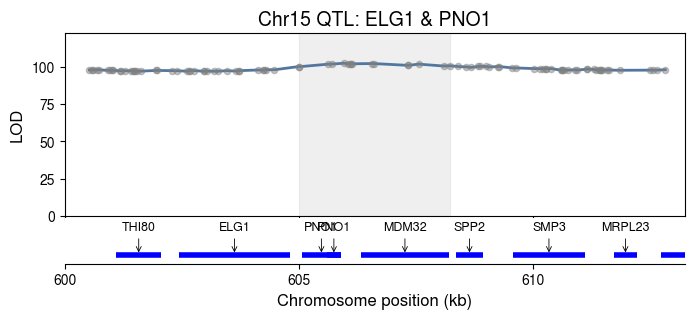

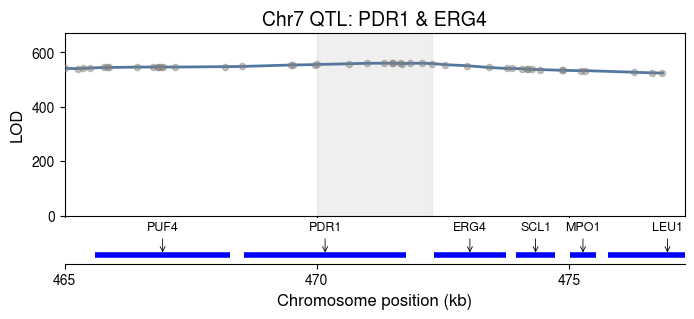

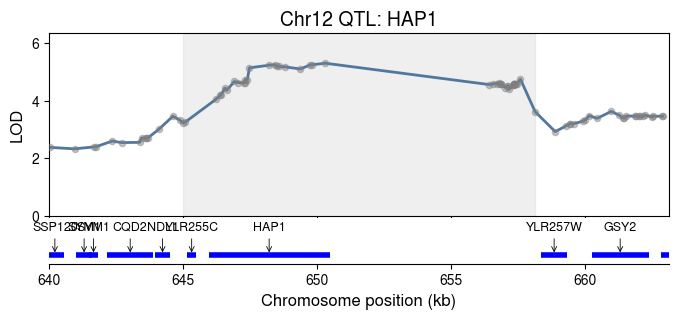

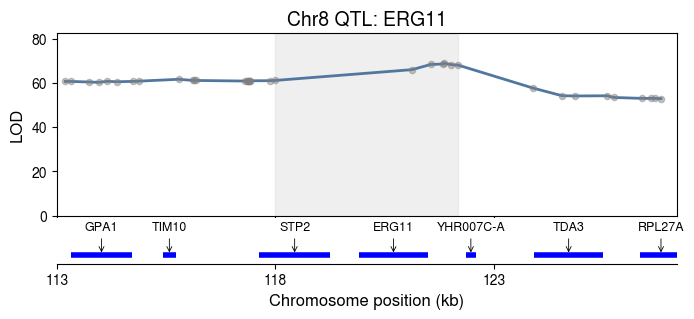

Saved all plots to: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/GRC


In [40]:
from pathlib import Path

# ==========================================================
# Generate zoomed-in Fluconazole QTL plots
# ==========================================================

# Output directory
OUTDIR = Path(
    "/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/GRC"
)
OUTDIR.mkdir(parents=True, exist_ok=True)

# Choose condition
treatment = "H"   # choose from: "C", "Q", "H", "F"

# Build LOD dataframe
df_plot = pd.DataFrame({
    "LOD": LODS_df[treatment]
})

# QTL windows to plot
qtl_windows = [
    {
        "chrom": 15,
        "start": 605280,
        "end": 608505,
        "ylim": None,
        "title": "Chr15 QTL: ELG1 & PNO1",
    },
    {
        "chrom": 7,
        "start": 470529,
        "end": 472821,
        "ylim": None,
        "title": "Chr7 QTL: PDR1 & ERG4",
    },
    {
        "chrom": 12,
        "start": 645451,
        "end": 658598,
        "ylim": None,
        "title": "Chr12 QTL: HAP1",
    },
    {
        "chrom": 8,
        "start": 118185,
        "end": 122368,
        "ylim": None,
        "title": "Chr8 QTL: ERG11",
    }
]

# Generate plots
for q in qtl_windows:

    fig, axs = plot_qtl_window_track_v2(
        df_plot=df_plot,
        snp_info=geno_data.snp_info,
        gene_info=gene_info_df,
        chrom=q["chrom"],
        chrom_range=(q["start"], q["end"]),
        value="LOD",
        ylab="LOD",
        ylim=q["ylim"],
        figsize=(8, 3),
        tick_step=5000,
        pad_bp=5000,
        title=q["title"]
    )

    # Save PDF (publication quality)
    fig.savefig(
        OUTDIR / f"{q['title']}.pdf",dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

print(f"Saved all plots to: {OUTDIR}")

In [26]:
gene_info_df.head()

,gene_name,chrom,gene_chr_start,gene_chr_end,Standard_name
0,YAL063C,1,24000,27968,FLO9
1,YAL062W,1,31567,32940,GDH3
2,YAL061W,1,33448,34701,BDH2
3,YAL060W,1,35155,36303,BDH1
4,YAL059C-A,1,36496,36918,ECM1


In [27]:
gene_info_df.dtypes

gene_name         object
chrom              int64
gene_chr_start     int64
gene_chr_end       int64
Standard_name     object
dtype: object

In [28]:
gene_info_df["chrom"].unique()[:20]

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16])

In [23]:
# plotting function for visualizing arbitrary chromosome segments

def plot_track(df_plot, snp_info, value, chrom=None, chrom_range=None, constrained_layout=False):
    df_plot, df_plot_max = make_df_plot(df_plot, snp_info)
    abs_pos = df_plot_max['abs_pos']
    y = df_plot_max.iloc[:, 0]
    ylab = value

    fig, ax = plt.subplots(figsize=(30, 10), gridspec_kw={'left': 0.4}, constrained_layout=constrained_layout)
    ax.set_box_aspect(1/6)
    
    # Plot main effect track
    ax.plot(
        df_plot['abs_pos'],
        df_plot[value],
        color='gray',
        lw=1.5,
        zorder=2, 
        alpha=.4
    )
    
    # Plot pleiotropic track
    ax.plot(
        pleio_track["abs_pos"], 
        200 * pleio_track["CI_track"]
    )
    
    # Draw vertical lines for chromosome boundaries
    for offset in chr_offsets[1:]:
        ax.axvline(offset, color='lightgray', lw=2, zorder=0)

    # Set x‐ticks at chromosome midpoints
    midpoints = [offset + length/2 for offset, length in zip(chr_offsets, yeast_chr_lengths)]
    ax.set_xticks(midpoints)
    ax.set_xticklabels(chr_labels_arabic, fontsize=12, fontweight='bold')
    if chrom is None:
        ax.set_xlim(0, yeast_chr_size)
        ax.set_xlabel('Chromosome', fontsize=18)
        
    else:
        chrom = chrom - 1
        chrom_size = chr_offsets[chrom + 1] - chr_offsets[chrom]
        
        ax.set_xticks(range(chr_offsets[chrom], chr_offsets[chrom + 1], 10000))
        xticks = np.arange(0, chrom_size, 10000)/10000
        xticks = np.array(xticks, int)
        ax.set_xticklabels(xticks)
        ax.set_xlabel('Chromosome position (10kb)', fontsize=18)        
        ax.set_title(f'Chromomsome {chrom + 1}')
        
        gene_info_chrom = gene_info_df[gene_info_df.chrom == chrom + 1].iloc[:, 1:]
        if chrom_range is not None:
            gene_info_chrom = gene_info_chrom[(gene_info_chrom['gene_chr_start'] > chrom_range[0]) & (gene_info_chrom['gene_chr_start'] < chrom_range[1])]
        for k in range(len(gene_info_chrom)):
            plot_gene(ax, *gene_info_chrom.iloc[k])
            
    
        if chrom_range is None:
            ax.set_xlim(chr_offsets[chrom], chr_offsets[chrom + 1])
        else:
            ax.set_xlim(chr_offsets[chrom] + chrom_range[0], chr_offsets[chrom] + chrom_range[1])

        # fig, ax = plt.subplots(figsize=(14, 4), gridspec_kw={'left': 0.4}, constrained_layout=constrained_layout)
        ax.set_box_aspect(1/6)

        ax.scatter(
            df_plot['abs_pos'],
            df_plot[value],
            color='gray',
            lw=1.5,
            zorder=2, 
            alpha=.4
        )
        
#     ax.set_ylabel(f'{ylab}', fontsize=18)
#     ax.margins(x=0)
    
    return ax

def plot_gene(ax, chrom, chr_start, chr_end, gene_name):
    abs_start, abs_end = get_abs_pos(chrom, chr_start), get_abs_pos(chrom, chr_end)
    ax.hlines(y=10, xmin=abs_start, xmax=abs_end, colors='red', linewidth=1)

    ax.text(
        (abs_start + abs_end) / 2,   # x position: midpoint of interval
        10 + 0.1,         # y position: slightly above the line
        gene_name,   # label
        ha='center',     # center horizontally
        va='bottom',      # anchor text at its bottom
        fontsize=12
    )

In [25]:
# Search any gene table you have
gene_info_df[gene_info_df.astype(str).apply(lambda c: c.str.contains(r"\bERG11\b", na=False)).any(axis=1)].head(10)

,gene_name,chrom,gene_chr_start,gene_chr_end,Standard_name
2093,YHR007C,8,120091,121683,ERG11


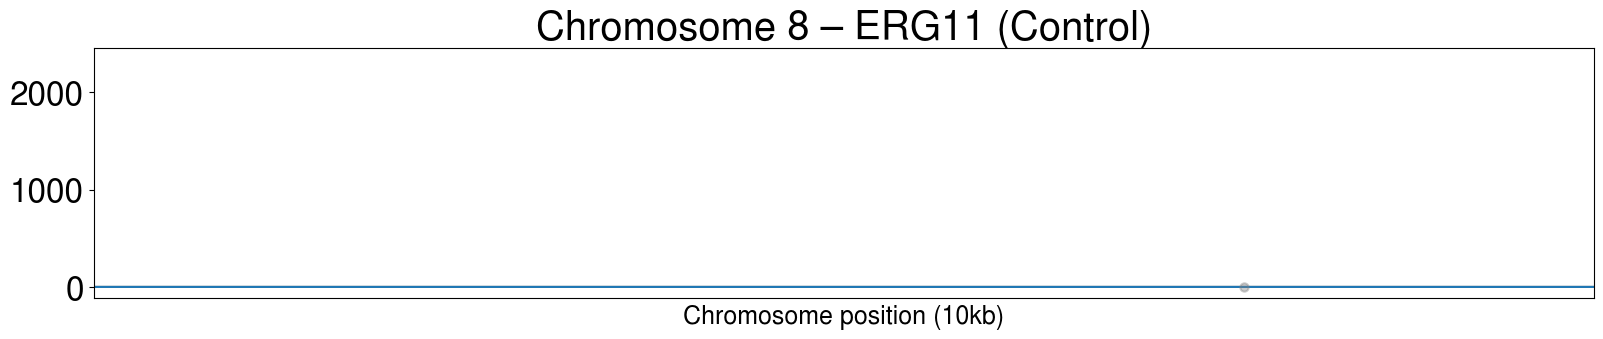

In [26]:
df_plot = pd.DataFrame({"LOD": LODS_df["C"]})

plot_track(
    df_plot,
    geno_data.snp_info,
    "LOD",
    chrom=8,
    chrom_range=[120091, 121683]
)

plt.title("Chromosome 8 – ERG11 (Control)")
plt.show()

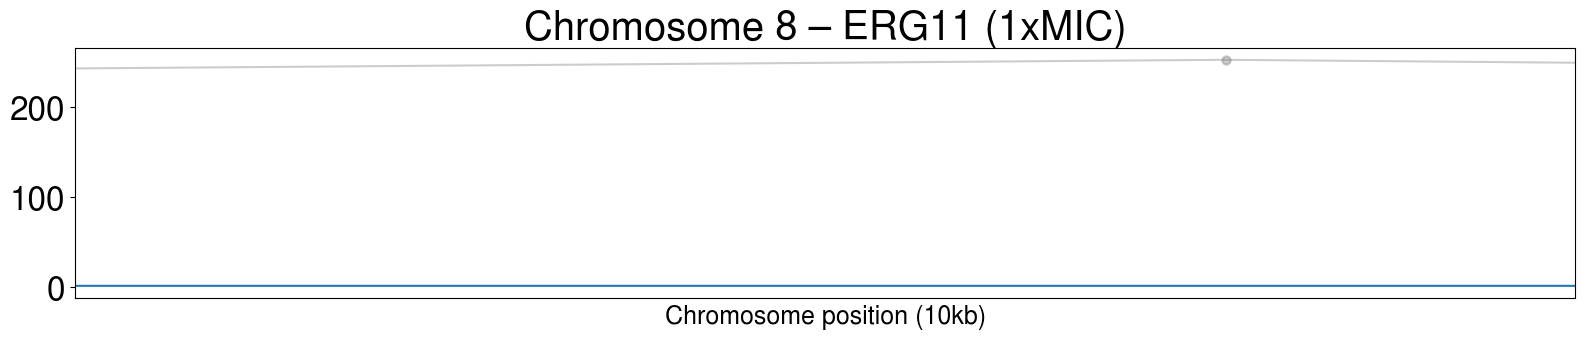

In [31]:
df_plot = pd.DataFrame({"LOD": LODS_df["F"]})

plot_track(
    df_plot,
    geno_data.snp_info,
    "LOD",
    chrom=8,
    chrom_range=[120091, 121683]
)

plt.title("Chromosome 8 – ERG11 (1xMIC)")
plt.show()

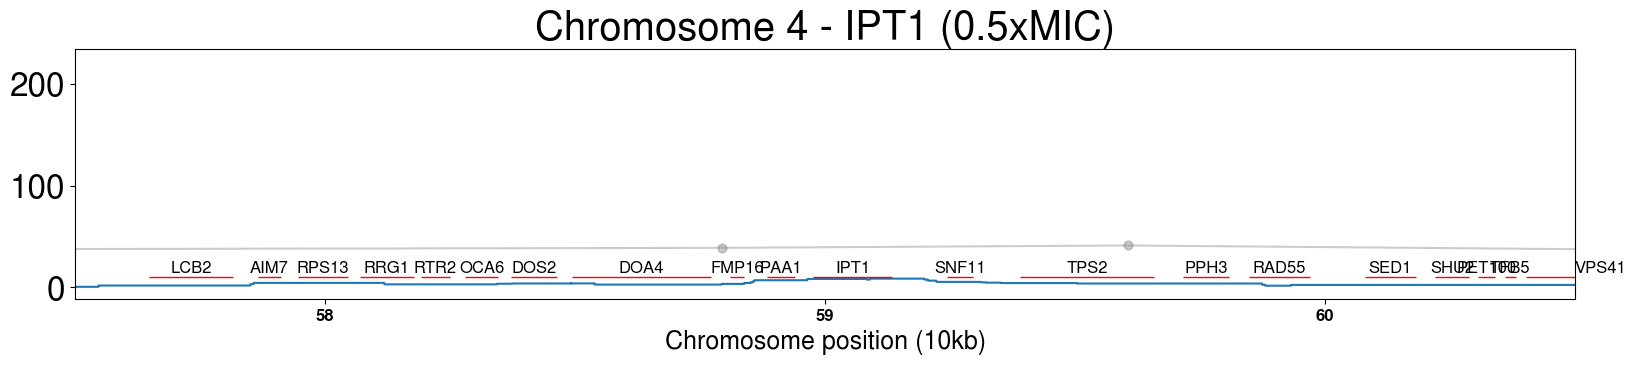

In [33]:
df_plot = pd.DataFrame({"LOD": LODS_df["H"]})  # change to H/F/D if needed

plot_track(
    df_plot,
    geno_data.snp_info,
    "LOD",
    chrom=4,
    chrom_range=[575000, 605000]
)

plt.title("Chromosome 4 - IPT1 (0.5xMIC)")
plt.show()

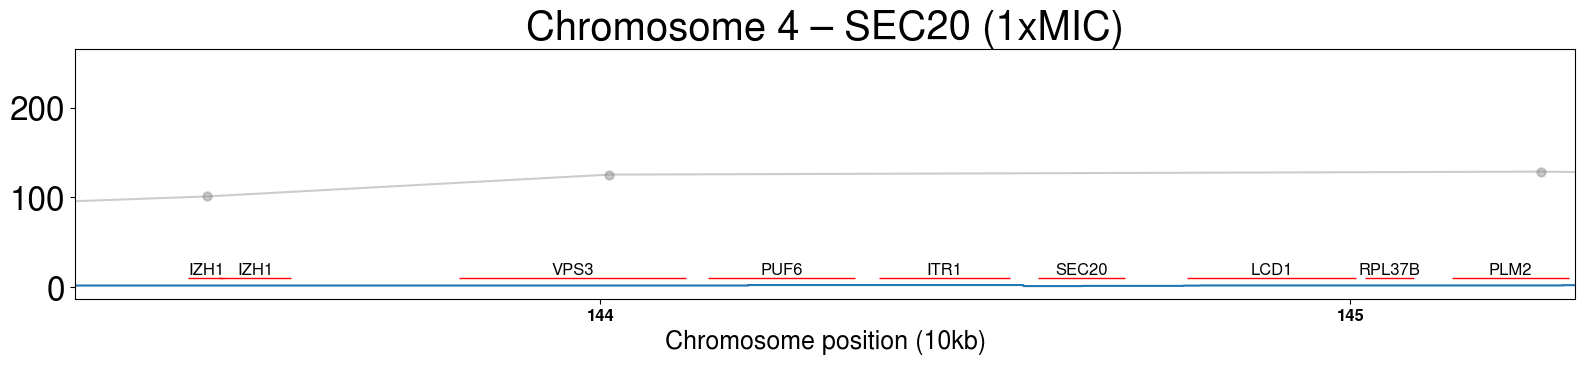

In [36]:
df_plot = pd.DataFrame({"LOD": LODS_df["F"]})  # change to C/H/D if needed

plot_track(
    df_plot,
    geno_data.snp_info,
    "LOD",
    chrom=4,
    chrom_range=[1433000, 1453000]
)

plt.title("Chromosome 4 – SEC20 (1xMIC)")
plt.show()

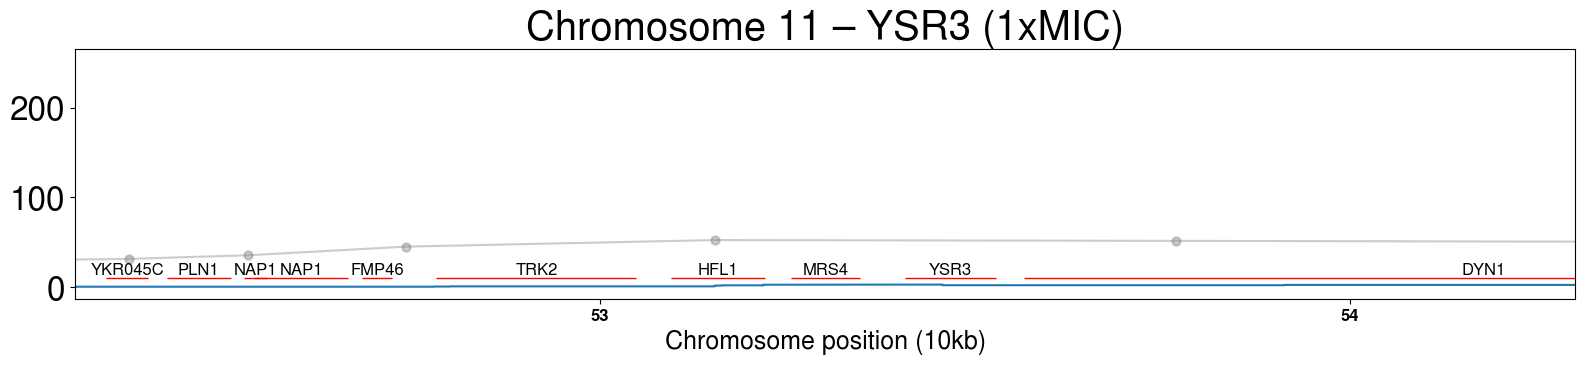

In [38]:
df_plot = pd.DataFrame({"LOD": LODS_df["F"]})

plot_track(
    df_plot,
    geno_data.snp_info,
    "LOD",
    chrom=11,
    chrom_range=[523000, 543000]
)

plt.title("Chromosome 11 – YSR3 (1xMIC)")
plt.show()

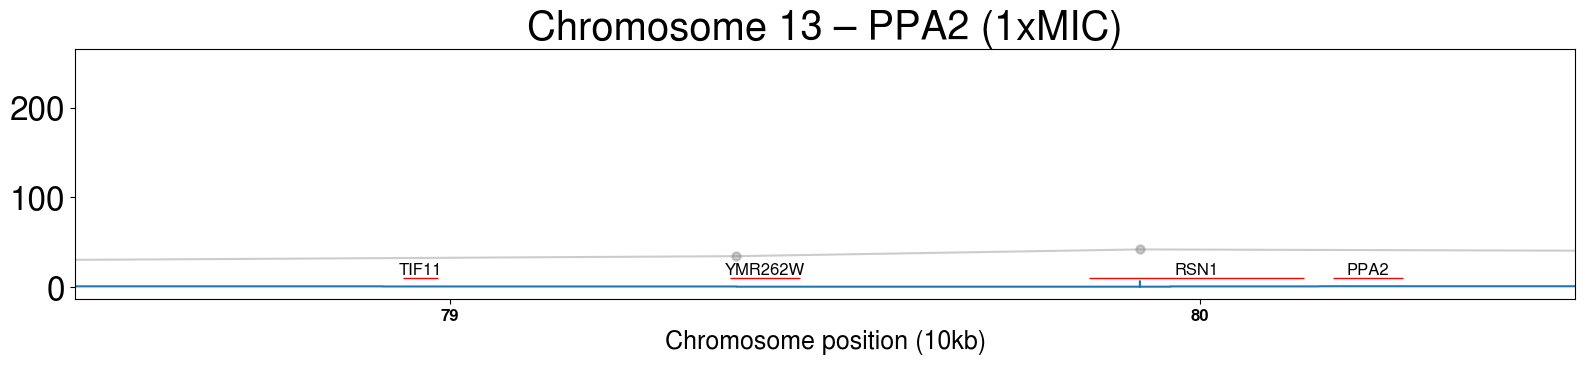

In [40]:
df_plot = pd.DataFrame({"LOD": LODS_df["F"]})

plot_track(
    df_plot,
    geno_data.snp_info,
    "LOD",
    chrom=13,
    chrom_range=[785000, 805000]
)

plt.title("Chromosome 13 – PPA2 (1xMIC)")
plt.show()